# Machine Learning Algorithms for Wine Classification

For this assignment we use the [UCI Wine dataset](https://archive.ics.uci.edu/dataset/109/wine). It contains 178 samples with 13 features, classified into 3 classes with [59, 71, 48] samples per class. The feature labels are:
- Alcohol Malicacid
- Ash
- Alcalinity_of_ash
- Magnesium
- Total_phenols
- Flavanoids
- Nonflavanoids_phenols
- Proanthocyanins
- Color_intensity
- Hue
- 0D280_0D315_of_diluted_wines
- Proline

All features are real positive numbers except for Proline and Magnesium, which are integers.
The goal is to classify a wine sample into one of the 3 classes.

scikit-learn gives us easy access to this data via load_wine().
# Setup:

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim

# Load the Wine dataset (features, integer class labels, and names)
data = load_wine()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset Loaded: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {target_names}")

# 80/20 train/test split, fixed seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (zero mean, unit variance) using train statistics only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dataset Loaded: 178 samples, 13 features
Classes: ['class_0' 'class_1' 'class_2']


## Method 1
### Principal Component Analysis:

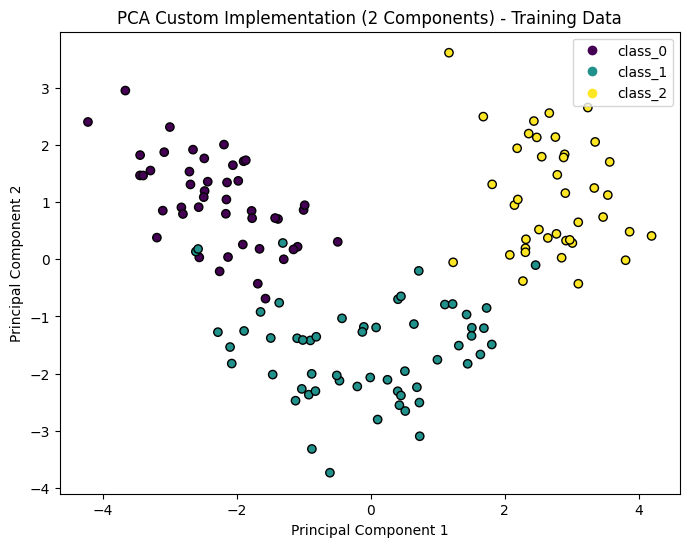

In [4]:
class CustomPCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        # Center the data, then compute the covariance matrix
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered.T)

        # Eigendecomposition of the covariance matrix
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        # Keep the eigenvectors with the largest eigenvalues (most variance explained)
        idxs = np.argsort(eigenvalues)[::-1]
        self.components = eigenvectors[:, idxs[:self.n_components]]

    def transform(self, X):
        # Project centered data onto the principal components
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# Reduce training data to 2 dimensions and visualize class separation
pca = CustomPCA(n_components=2)
pca.fit(X_train_scaled)
X_projected_train = pca.transform(X_train_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_projected_train[:, 0], X_projected_train[:, 1], c=y_train, cmap='viridis', edgecolor='k')
plt.title('PCA Custom Implementation (2 Components) - Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=list(target_names))
plt.show()

## Method 2
### Least Squares Algorithm:

In [5]:
class LeastSquares:
    def __init__(self):
        self.W = None

    def fit(self, X, y):
        # Add bias column (intercept term)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # One-hot encode labels so we can solve for a weight matrix via regression
        n_classes = len(np.unique(y))
        y_one_hot = np.eye(n_classes)[y]

        # Closed-form least squares solution: W = (X^T * X)^-1 * X^T * Y
        self.W = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_one_hot)

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        predictions = X_b.dot(self.W)
        # Predicted class = column (class) with the highest regression score
        return np.argmax(predictions, axis=1)

ls_clf = LeastSquares()
ls_clf.fit(X_train_scaled, y_train)
y_pred_ls = ls_clf.predict(X_test_scaled)

print(f"Least Squares Accuracy: {accuracy_score(y_test, y_pred_ls):.4f}")

Least Squares Accuracy: 1.0000


## Method 3
### Logistic Regression with Stochastic Gradient Descent

Logistic Regression Accuracy: 1.0000


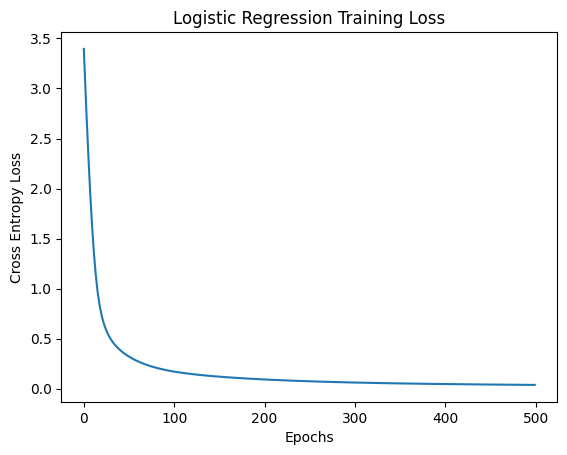

In [6]:
class LogisticRegressionSGD:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.train_losses = []

    def softmax(self, z):
        # Subtract row-wise max for numerical stability before exponentiating
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        self.weights = np.random.randn(n_features, n_classes)
        self.bias = np.zeros((1, n_classes))

        y_one_hot = np.eye(n_classes)[y]

        for epoch in range(self.epochs):
            # Forward pass: linear scores -> softmax probabilities
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.softmax(linear_model)

            # Cross-entropy loss (epsilon avoids log(0))
            loss = -np.mean(np.sum(y_one_hot * np.log(y_pred + 1e-9), axis=1))
            self.train_losses.append(loss)

            # Gradients of cross-entropy loss w.r.t. weights and bias
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y_one_hot))
            db = (1/n_samples) * np.sum(y_pred - y_one_hot, axis=0)

            # Gradient descent update (full-batch here, despite the class name)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.softmax(linear_model)
        return np.argmax(y_pred, axis=1)


log_reg = LogisticRegressionSGD(learning_rate=0.1, epochs=500)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

# Plot training loss curve to check convergence
plt.plot(log_reg.train_losses)
plt.title('Logistic Regression Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.show()

## Method 4
### K-Nearest-Neighbors Algorithm:
Optimal value of hyperparameter k: 8

K=1, Accuracy: 0.9444
K=2, Accuracy: 0.9444
K=3, Accuracy: 0.9444
K=4, Accuracy: 0.9444
K=5, Accuracy: 0.9444
K=6, Accuracy: 0.9444
K=7, Accuracy: 0.9444
K=8, Accuracy: 0.9722
K=9, Accuracy: 0.9444


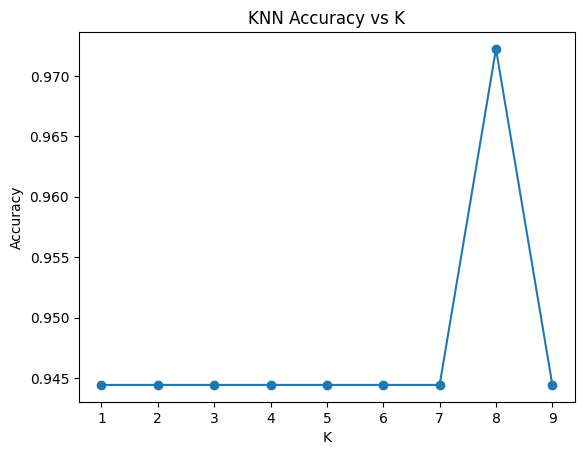

In [7]:
class CustomKNN:
  def __init__(self, k=3):
    self.k = k

  def fit(self, X, y):
    # KNN is lazy: just store the training data
    self.X_train = X
    self.y_train = y

  def predict(self, X):
        predictions = [self.predict2(x) for x in X]
        return np.array(predictions)

  def predict2(self, x):
        # Euclidean distance from x to every training point
        distances = [np.sqrt(np.sum((x_train - x)**2)) for x_train in self.X_train]

        # Indices of the k closest training points
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Majority vote among the k nearest labels
        most_common = np.bincount(k_nearest_labels).argmax()
        return most_common

# Sweep k from 1 to 9 to find the best-performing value on the test set
accuracies = []
k_range = range(1, 10)

for k in k_range:
    knn = CustomKNN(k=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)
    print(f"K={k}, Accuracy: {acc:.4f}")


plt.plot(k_range, accuracies, marker='o')
plt.title('KNN Accuracy vs K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

## Method 5
### Naive Bayes:

In [8]:
class CustomGaussianNB:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        self.mean = np.zeros((n_classes, n_features))
        self.var = np.zeros((n_classes, n_features))
        self.priors = np.zeros(n_classes)

        # Per-class mean/variance (Gaussian likelihood params) and class prior
        for idx, c in enumerate(self.classes):
            X_c = X[y == c]

            self.mean[idx, :] = X_c.mean(axis=0)
            self.var[idx, :] = X_c.var(axis=0)
            self.priors[idx] = X_c.shape[0] / n_samples

    def _pdf(self, class_idx, x):
        # Gaussian probability density per feature, assuming feature independence
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(- (x - mean)**2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        y_pred = []
        for x in X:
            posteriors = []
            for idx, c in enumerate(self.classes):
                # Use log-probabilities to avoid underflow from multiplying small densities
                prior = np.log(self.priors[idx])

                class_conditional = np.sum(np.log(self._pdf(idx, x)))

                posterior = prior + class_conditional
                posteriors.append(posterior)

            # Predict the class with the highest posterior probability
            y_pred.append(self.classes[np.argmax(posteriors)])

        return np.array(y_pred)

nb = CustomGaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
print(f"Naive Bayes Accuracy on Test: {accuracy_score(y_test, y_pred_nb):.4f}")

Naive Bayes Accuracy on Test: 1.0000


## Method 6
### Multilayer Perceptron:

MLP Pytorch Final Accuracy: 1.0000


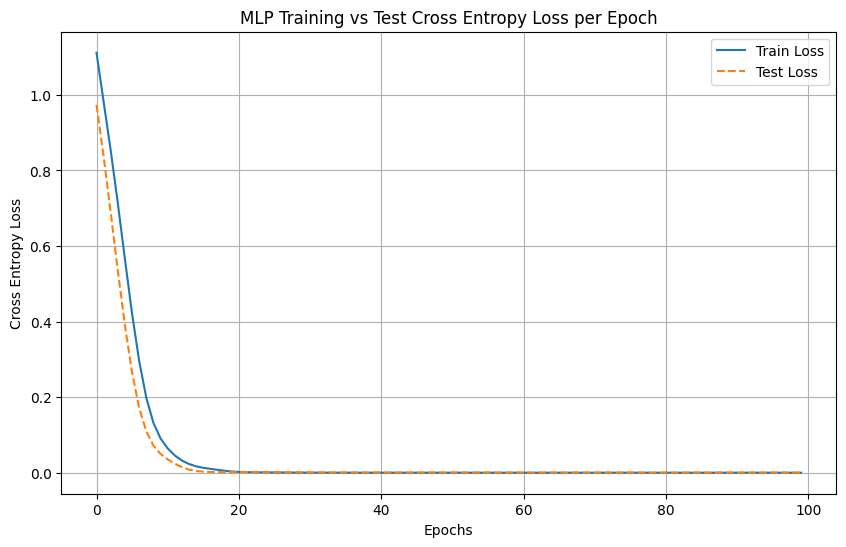

In [9]:
# Convert numpy arrays to torch tensors for PyTorch training
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.LongTensor(y_test)


class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        # 3 fully-connected layers: input -> 64 -> 32 -> output, ReLU activations
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out


model = MLP(input_dim=X_train.shape[1], output_dim=3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training step: forward pass, backprop, weight update
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Evaluation step: track test loss without updating weights
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        t_loss = criterion(test_outputs, y_test_t)
        test_losses.append(t_loss.item())


model.eval()
with torch.no_grad():
    final_outputs = model(X_test_t)
    _, predicted = torch.max(final_outputs, 1)
    acc = (predicted == y_test_t).sum().item() / len(y_test_t)
    print(f"MLP Pytorch Final Accuracy: {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss', linestyle='--')
plt.title('MLP Training vs Test Cross Entropy Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

## Method 7
### Support Vector Machine:
Implementing a MulticlassSVM and visualizing results on the test data.

SVM Accuracy on Test: 1.0000


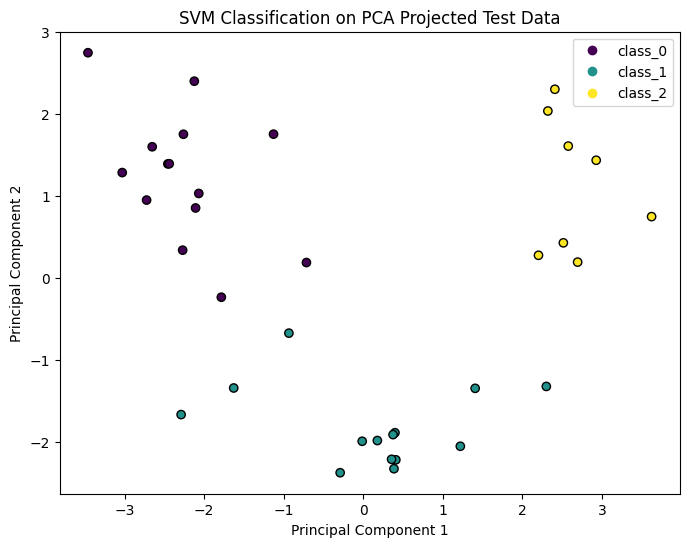

In [10]:
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        # Binary SVM trained with hinge loss; labels mapped to {-1, +1}
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1)

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # Check if the sample is correctly classified outside the margin
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    # Only regularization gradient applies (no margin violation)
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Regularization + hinge loss gradient (margin violated)
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))

                    self.b -= self.lr * y_[idx]


    def decision_function(self, X):
        return np.dot(X, self.w) - self.b


    def predict(self, X):
        linear_output = self.decision_function(X)
        return np.sign(linear_output)


class MulticlassSVM:
    def __init__(self, n_iters=1000):
        self.n_iters = n_iters
        self.classifiers = []
        self.classes = None

    def fit(self, X, y):
        # One-vs-rest: train one binary SVM per class
        self.classes = np.unique(y)
        self.classifiers = []

        for c in self.classes:
            y_bin = np.where(y == c, 1, -1)

            clf = SVM(n_iters=self.n_iters)
            clf.fit(X, y_bin)
            self.classifiers.append(clf)

    def predict(self, X):
        # Predict the class whose binary classifier gives the highest decision score
        scores = np.zeros((X.shape[0], len(self.classes)))

        for idx, clf in enumerate(self.classifiers):
            scores[:, idx] = clf.decision_function(X)

        return self.classes[np.argmax(scores, axis=1)]



svm2 = MulticlassSVM(n_iters=1000)
svm2.fit(X_train_scaled, y_train)
y_pred_svm = svm2.predict(X_test_scaled)

print(f"SVM Accuracy on Test: {accuracy_score(y_test, y_pred_svm):.4f}")

# Visualize SVM predictions on the same PCA projection used earlier
X_projected_test = pca.transform(X_test_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_projected_test[:, 0], X_projected_test[:, 1], c=y_pred_svm, cmap='viridis', edgecolor='k')
plt.title('SVM Classification on PCA Projected Test Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=list(target_names))
plt.show()

## Method 8
### K-Means Algorithm:

Converged at iteration 7



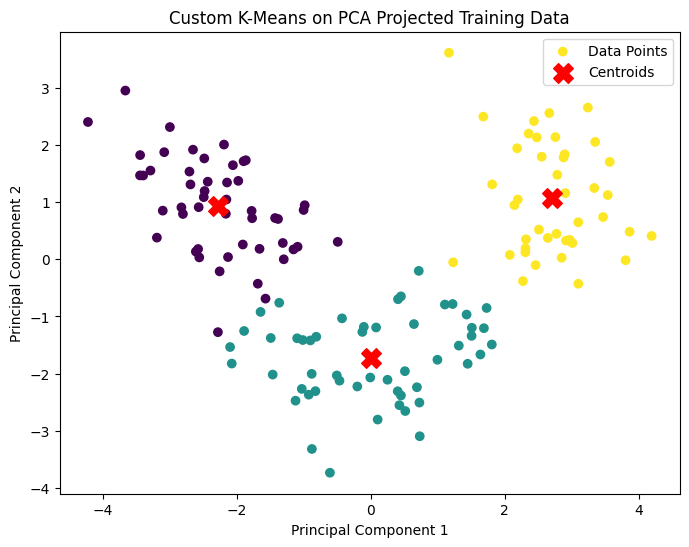

In [11]:
class CustomKMeans:
    def __init__(self, n_clusters=3, max_iters=15):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.centroids = None
        self.labels = None

    def fit(self, X):
        n_samples, n_features = X.shape

        # Initialize centroids by picking random data points
        random_indices = np.random.choice(n_samples, size=self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for i in range(self.max_iters):
            # Assignment step: assign each point to its nearest centroid
            distances = np.sqrt(((X - self.centroids[:, np.newaxis])**2).sum(axis=2))
            self.labels = np.argmin(distances, axis=0)

            old_centroids = self.centroids.copy()

            # Update step: move each centroid to the mean of its assigned points
            for k in range(self.n_clusters):
                points = X[self.labels == k]

                if len(points) > 0:
                    self.centroids[k] = points.mean(axis=0)

            # Stop early if centroids no longer move
            if np.allclose(old_centroids, self.centroids):
                print(f"Converged at iteration {i}\n")
                break



        return np.array(self.centroids)


kmeans = CustomKMeans(n_clusters=3, max_iters=10)
# Fit K-Means on the PCA-projected training data
centroids = kmeans.fit(X_projected_train)

plt.figure(figsize=(8, 6))
plt.scatter(X_projected_train[:, 0], X_projected_train[:, 1], c=kmeans.labels, cmap='viridis', label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("Custom K-Means on PCA Projected Training Data")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()